In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

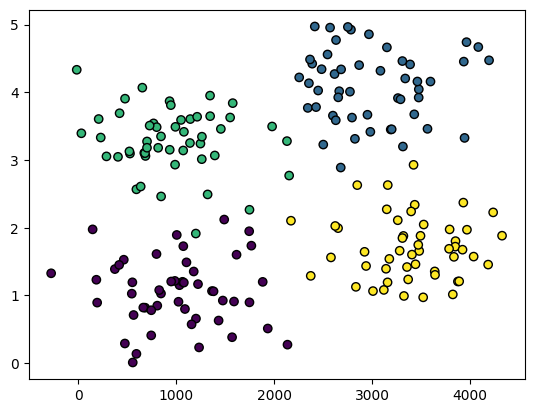

In [2]:
blob_centers = ([1, 1], [3, 4], [1, 3.3], [3.5, 1.8])
X, y = make_blobs(n_samples=200, 
                          centers=blob_centers, 
                          cluster_std=0.5,
                          random_state=0)

X[:, 0] *= 1000

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)

In [3]:
from sklearn.neural_network import MLPClassifier
clf = MLPClassifier(hidden_layer_sizes=(6,), 
                    random_state=1).fit(X, y)

In [4]:
print("Веса между входным и скрытым слоем:")
print(clf.coefs_[0])
print("\nВеса между скрытым и выходным слоем:")
print(clf.coefs_[1])

Веса между входным и скрытым слоем:
[[-0.09809877  0.33667051 -0.82024119 -0.29720839 -0.56852789 -0.66056109]
 [-0.58903611 -0.31219238 -0.22424296  0.11423652 -0.18324369  0.37321781]]

Веса между скрытым и выходным слоем:
[[-0.51316658 -0.43365467  0.43189995  0.68148414]
 [-0.24370005  0.34328608  0.57835494  0.57889271]
 [-0.59713359 -0.67678056 -0.46609801  0.54011704]
 [-0.5769702  -0.10221922  0.75476969  0.00610289]
 [ 0.34285864 -0.25645017  0.33417991  0.47281254]
 [-0.7006119   0.35515533  0.80295119  0.33880635]]


In [5]:
for i in range(len(clf.coefs_)):
    number_neurons_in_layer = clf.coefs_[i].shape[1]
    for j in range(number_neurons_in_layer):
        weights = clf.coefs_[i][:,j]
        print(i, j, weights, end=", ")
        print()
    print()

0 0 [-0.09809877 -0.58903611], 
0 1 [ 0.33667051 -0.31219238], 
0 2 [-0.82024119 -0.22424296], 
0 3 [-0.29720839  0.11423652], 
0 4 [-0.56852789 -0.18324369], 
0 5 [-0.66056109  0.37321781], 

1 0 [-0.51316658 -0.24370005 -0.59713359 -0.5769702   0.34285864 -0.7006119 ], 
1 1 [-0.43365467  0.34328608 -0.67678056 -0.10221922 -0.25645017  0.35515533], 
1 2 [ 0.43189995  0.57835494 -0.46609801  0.75476969  0.33417991  0.80295119], 
1 3 [0.68148414 0.57889271 0.54011704 0.00610289 0.47281254 0.33880635], 



In [6]:
print("Веса смещения для скрытого слоя:")
print(clf.intercepts_[0])
print("\nВеса смещения для выходного слоя:")
print(clf.intercepts_[1])

Веса смещения для скрытого слоя:
[-0.55752645  0.60978582 -0.8640854   0.33258994 -0.18652436  0.05696655]

Веса смещения для выходного слоя:
[-0.29413473  0.49414359 -0.60792984 -0.11888525]


In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix
confusion_matrix(y, clf.predict(X))

array([[ 0,  0,  0, 50],
       [ 0,  0,  0, 50],
       [ 0,  0,  0, 50],
       [ 0,  0,  0, 50]])

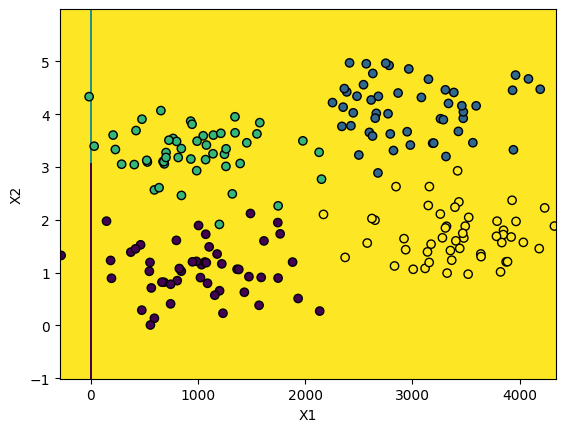

In [8]:
X0 = np.linspace(X[:, 0].min()-1,X[:, 0].max()+1, X.shape[0])
X1 = np.linspace(X[:, 1].min()-1,X[:, 1].max()+1, X.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X = scaler.transform(X)

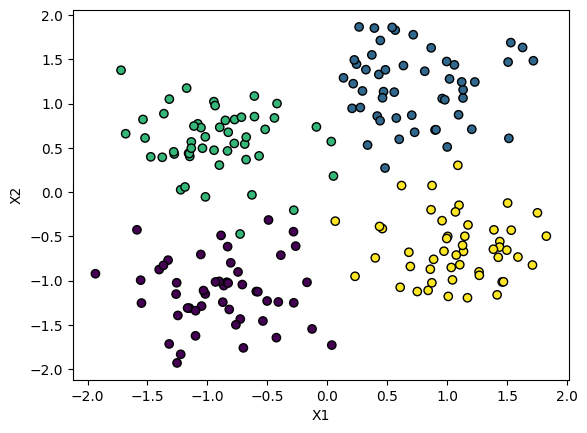

In [10]:
X0 = np.linspace(X[:, 0].min()-1,X[:, 0].max()+1, X.shape[0])
X1 = np.linspace(X[:, 1].min()-1,X[:, 1].max()+1, X.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

In [12]:
clf_scaled = MLPClassifier(hidden_layer_sizes=(6,), 
                    random_state=1, max_iter=10000).fit(X, y)

In [13]:
from sklearn.metrics import accuracy_score, confusion_matrix
confusion_matrix(y, clf_scaled.predict(X))

array([[50,  0,  0,  0],
       [ 0, 49,  0,  1],
       [ 2,  3, 45,  0],
       [ 0,  1,  0, 49]])

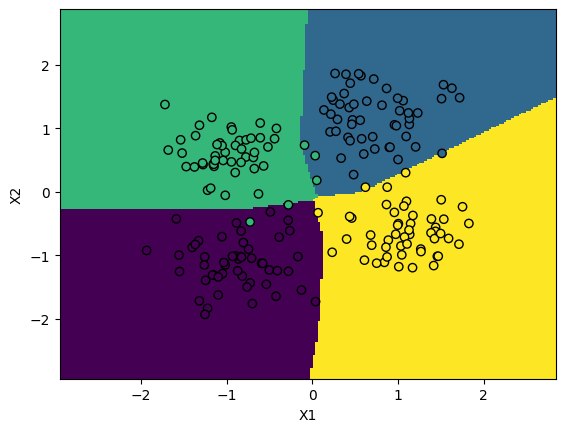

In [16]:
X0 = np.linspace(X[:, 0].min()-1,X[:, 0].max()+1, X.shape[0])
X1 = np.linspace(X[:, 1].min()-1,X[:, 1].max()+1, X.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf_scaled.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

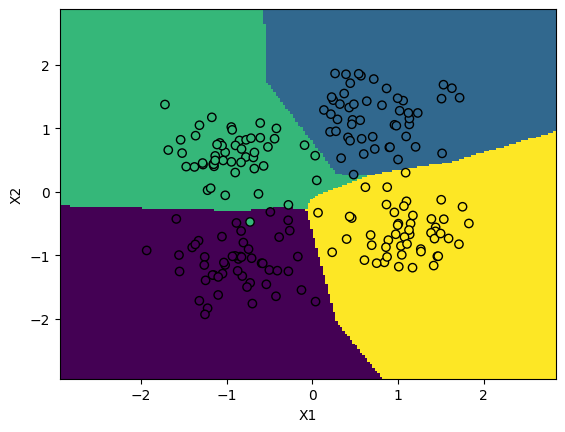

In [18]:
clf = MLPClassifier(hidden_layer_sizes=(6, 6, 6), max_iter=10_000).fit(X, y)
X0 = np.linspace(X[:, 0].min()-1,X[:, 0].max()+1, X.shape[0])
X1 = np.linspace(X[:, 1].min()-1,X[:, 1].max()+1, X.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

# task

In [19]:
neuron_count = [1, 2, 10, 100]
for count in neuron_count:
    clf = MLPClassifier(hidden_layer_sizes=(count,), max_iter=10_000).fit(X, y)
    y_predict = clf.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
    accuracy = accuracy_score(y, clf.predict(X))
    print(f"neuron count: {count} accuracy: {accuracy:.4f}")

neuron count: 1 accuracy: 0.6600
neuron count: 2 accuracy: 0.9800
neuron count: 10 accuracy: 0.9800
neuron count: 100 accuracy: 0.9950


In [20]:
neuron_count = 6
depth = [2, 3, 10]
for d in depth:
    clf = MLPClassifier(hidden_layer_sizes=(neuron_count,)*d, max_iter=10_000).fit(X, y)
    y_predict = clf.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
    accuracy = accuracy_score(y, clf.predict(X))
    print(f"depth: {d} accuracy: {accuracy:.4f}")

depth: 2 accuracy: 0.9800
depth: 3 accuracy: 0.9850
depth: 10 accuracy: 0.9950


In [22]:
clf = MLPClassifier(hidden_layer_sizes=(6, 6, 6), max_iter=10_000).fit(X, y)

for layer_idx, (W, b) in enumerate(zip(clf.coefs_, clf.intercepts_)):
    print(f"layer {layer_idx} weights (shape {W.shape}):")
    print(W)
    print(f"layer {layer_idx} biases (shape {b.shape}):")
    print(b)

layer 0 weights (shape (2, 6)):
[[ 0.31371644 -0.74709182  1.46642258 -1.18476023 -1.43741476 -1.28115811]
 [-1.19527916 -1.16529167 -1.06473888 -0.22086278 -0.48340053 -0.59711177]]
layer 0 biases (shape (6,)):
[ 0.53917031 -0.34024097  0.56219263  0.57980073  0.90544485  0.30351063]
layer 1 weights (shape (6, 6)):
[[ 1.12369497 -1.1375867  -0.13628954 -0.23489399 -1.26866138  0.32932209]
 [ 0.19764372 -1.10117538 -1.49257991 -0.08881562 -0.47532521  0.78602903]
 [ 0.77968902  0.00534183 -0.91146428  0.33988653  0.00978919 -0.39419478]
 [-0.50182905 -0.11172891  1.3440087  -0.91698122 -0.52947663  1.01550662]
 [ 0.94603147  0.45721435  0.59754441 -0.428935   -0.18555516  0.74206985]
 [ 1.19660714  0.47246365 -0.1826791   0.43741374  0.05930231  0.66131796]]
layer 1 biases (shape (6,)):
[ 0.34734457  0.92017831  0.04152947  1.14728773  0.89711961 -0.00364146]
layer 2 weights (shape (6, 6)):
[[ 8.59541971e-03  8.72432468e-01  5.26233502e-01 -6.87344225e-01
  -2.20972610e-02  9.16055761e

In [33]:
from time import perf_counter

t = perf_counter()
MLPClassifier(hidden_layer_sizes=(6,), max_iter=10_000).fit(X, y)
print(f"Time taken for a simple model: {perf_counter() - t:.4f} seconds")

t = perf_counter()
MLPClassifier(hidden_layer_sizes=(12, 12, 12, 12, 12, 12), max_iter=10_000).fit(X, y)
print(f"Time taken for a complex model: {perf_counter() - t:.4f} seconds")

Time taken for a simple model: 0.4585 seconds
Time taken for a complex model: 0.3080 seconds


In [36]:
from sklearn import datasets
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

data = datasets.load_breast_cancer()
X, y = data.data, data.target
print("features:", data.feature_names)
print("classes :", data.target_names)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y)

percep = Perceptron(max_iter=1000, tol=1e-3, random_state=0)
percep.fit(X_train, y_train)

y_pred = percep.predict(X_test)
print("accuracy:", accuracy_score(y_test, y_pred))
print("confusion matrix:\n", confusion_matrix(y_test, y_pred))

features: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
classes : ['malignant' 'benign']
accuracy: 0.9298245614035088
confusion matrix:
 [[ 53  11]
 [  1 106]]


In [38]:
data = datasets.load_diabetes()
X, y = data.data, data.target

threshold = np.median(y)
y_class = (y > threshold).astype(int)  # idk we cant use perceptron for regression so we make it a classification problem

X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.3, random_state=0, stratify=y_class)

percep = Perceptron(max_iter=1000, tol=1e-3, random_state=0)
percep.fit(X_train, y_train)

y_pred = percep.predict(X_test)
print("accuracy:", accuracy_score(y_test, y_pred))
print("confusion matrix:\n", confusion_matrix(y_test, y_pred))

accuracy: 0.7443609022556391
confusion matrix:
 [[51 16]
 [18 48]]
